<a href="https://colab.research.google.com/github/leejuheon06/Practice_ML_1/blob/main/03_%EC%B2%98%EC%9D%8C_%EC%8B%9C%EC%9E%91%ED%95%98%EB%8A%94_%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [2]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1

In [1]:
# 라이브러리 임포트

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

In [2]:
# 파이토치 관련 라이브러리
import torch
from torchviz import make_dot

In [3]:
# 기본 폰트 설정
plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

In [4]:
# warning 표시 끄기
import warnings
warnings.simplefilter('ignore')

3.5 데이터 전처리

In [5]:
# 샘플 데이터 선언 (신장, 체중)
sampleData1 = np.array([
    [166, 58.7],
    [176.0, 75.7],
    [171.0, 62.1],
    [173.0, 70.4],
    [169.0, 60.1]
])
print(type(sampleData1))
print(sampleData1)

<class 'numpy.ndarray'>
[[166.   58.7]
 [176.   75.7]
 [171.   62.1]
 [173.   70.4]
 [169.   60.1]]


In [7]:
# x : 신장, y : 체중

x = sampleData1[:, 0]
y = sampleData1[:, 1]
print(x)
print(y)

[166. 176. 171. 173. 169.]
[58.7 75.7 62.1 70.4 60.1]


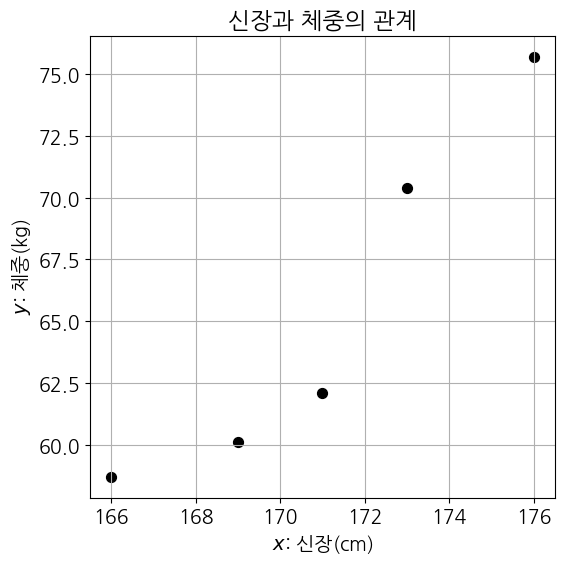

In [8]:
# 산포도 출력
plt.scatter(x, y, c='k', s=50)
plt.xlabel('$x$: 신장(cm)')
plt.ylabel('$y$: 체중(kg)')
plt.title('신장과 체중의 관계')
plt.show()

In [9]:
# 데이터 변환
# 평균값을 빼주면 경사 하강법이 수월해짐
X = x - x.mean()
Y = y - y.mean()

In [10]:
print(X)
print(Y)

[-5.  5.  0.  2. -2.]
[-6.7 10.3 -3.3  5.  -5.3]


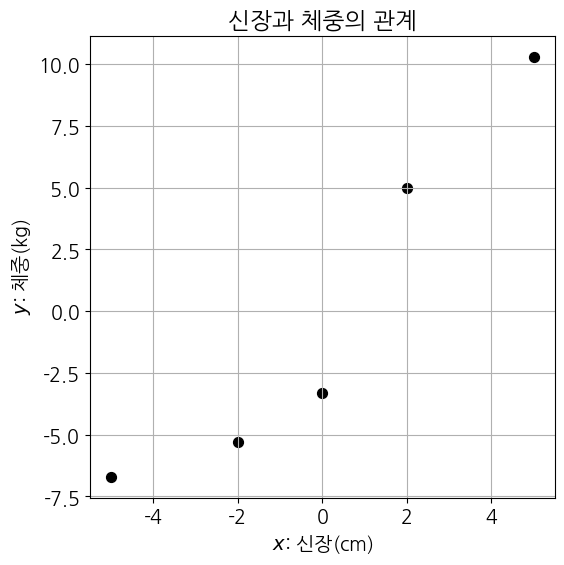

In [11]:
plt.scatter(X, Y, c='k', s=50)
plt.xlabel('$x$: 신장(cm)')
plt.ylabel('$y$: 체중(kg)')
plt.title('신장과 체중의 관계')
plt.show()

3.6 예측 계산

In [12]:
# X와 Y를 토치로 변환
X = torch.tensor(X).float()
Y = torch.tensor(Y).float()

In [13]:
print(X)
print(Y)

tensor([-5.,  5.,  0.,  2., -2.])
tensor([-6.7000, 10.3000, -3.3000,  5.0000, -5.3000])


In [14]:
# 파라미터 정의
# W, B는 경사 계산을 위해 requires_grad=True 설정
W = torch.tensor(1.0, requires_grad=True).float()
B = torch.tensor(1.0, requires_grad=True).float()

In [15]:
print(W)
print(B)

tensor(1., requires_grad=True)
tensor(1., requires_grad=True)


In [16]:
# 예측 1차 함수
def pred(X):
  return W * X + B

In [17]:
Yp = pred(X)
print(Yp)

tensor([-4.,  6.,  1.,  3., -1.], grad_fn=<AddBackward0>)


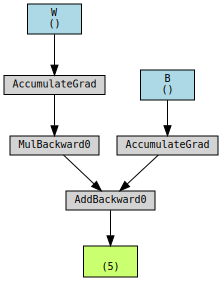

In [18]:
# Yp 계산 그래프
params = {'W': W, 'B': B}
g = make_dot(Yp, params=params)
display(g)

3.7 손실 계산

In [19]:
# 평균 제곱 오차(MSE) 손실함수
def mse(Yp, Y):
  loss = ((Yp - Y)**2).mean()
  return loss

In [20]:
loss = mse(Yp, Y)
print(loss)

tensor(13.3520, grad_fn=<MeanBackward0>)


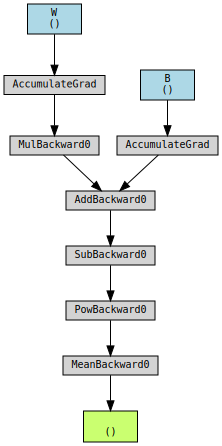

In [21]:
# 손실 계산 그래프
params = {'W': W, 'B': B}
g = make_dot(loss, params=params)
display(g)

3.8 경사 계산

In [22]:
loss.backward()

In [23]:
# 경사값 확인
print(W.grad)
print(B.grad)

tensor(-19.0400)
tensor(2.0000)


3.9 파라미터 수정

In [ ]:
# with torch.no_grad():
#   # 파라미터 수정
#   W -= lr*W.grad
#   B -= lr*B.grad

#   # 경사값 초기화
#   W.grad.zero_()
#   B.grad.zero_()

In [35]:
print(W)
print(B)
print(W.grad)
print(B.grad)

tensor(1.8207, requires_grad=True)
tensor(0.0182, requires_grad=True)
tensor(0.)
tensor(0.)


3.10 반복 계산

In [36]:
# 초기화

W = torch.tensor(1.0, requires_grad=True).float()
B = torch.tensor(1.0, requires_grad=True).float()

# 반복 횟수
num_epochs = 500

# 학습률
lr = 0.001

# history 기록을 위한 배열 초기화
history = np.zeros((0,2))

In [37]:
# 루프 처리

for epoch in range(num_epochs):
  # 예측 계산
  Yp = pred(X)

  # 손실 계산
  loss = mse(Yp, Y)

  # 경사 계산
  loss.backward()

  with torch.no_grad():
    # 파라미터 수정
    W -= lr*W.grad
    B -= lr*B.grad

    # 경사값 초기화
    W.grad.zero_()
    B.grad.zero_()

  # 손실 기록
  if (epoch % 10 == 0):
    item = np.array([epoch, loss.item()])
    history = np.vstack((history, item))
    print(f'epoch = {epoch} loss = {loss:.4f}')

epoch = 0 loss = 13.3520
epoch = 10 loss = 10.3855
epoch = 20 loss = 8.5173
epoch = 30 loss = 7.3364
epoch = 40 loss = 6.5858
epoch = 50 loss = 6.1047
epoch = 60 loss = 5.7927
epoch = 70 loss = 5.5868
epoch = 80 loss = 5.4476
epoch = 90 loss = 5.3507
epoch = 100 loss = 5.2805
epoch = 110 loss = 5.2275
epoch = 120 loss = 5.1855
epoch = 130 loss = 5.1507
epoch = 140 loss = 5.1208
epoch = 150 loss = 5.0943
epoch = 160 loss = 5.0703
epoch = 170 loss = 5.0480
epoch = 180 loss = 5.0271
epoch = 190 loss = 5.0074
epoch = 200 loss = 4.9887
epoch = 210 loss = 4.9708
epoch = 220 loss = 4.9537
epoch = 230 loss = 4.9373
epoch = 240 loss = 4.9217
epoch = 250 loss = 4.9066
epoch = 260 loss = 4.8922
epoch = 270 loss = 4.8783
epoch = 280 loss = 4.8650
epoch = 290 loss = 4.8522
epoch = 300 loss = 4.8399
epoch = 310 loss = 4.8281
epoch = 320 loss = 4.8167
epoch = 330 loss = 4.8058
epoch = 340 loss = 4.7953
epoch = 350 loss = 4.7853
epoch = 360 loss = 4.7756
epoch = 370 loss = 4.7663
epoch = 380 loss = 4.

In [38]:
# 최종 파라미터 값
print(f"W = {W.data.numpy()}")
print(f"B = {B.data.numpy()}")

# 손실 확인
print(f"초기상태 = 손실 :{history[0,1]:.4f}")
print(f"초기상태 = 손실 :{history[-1,1]:.4f}")

W = 1.8206830024719238
B = 0.3675113916397095
초기상태 = 손실 :13.3520
초기상태 = 손실 :4.6796


3.11 결과 평가

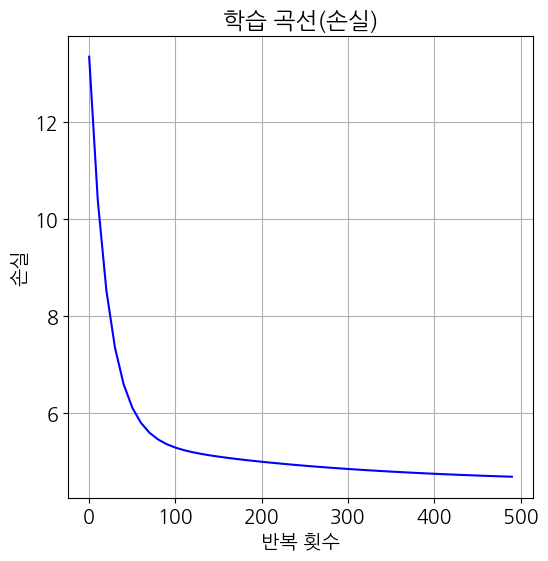

In [39]:
# 학습 곡선 출력(손실)

plt.plot(history[:,0], history[:,1], 'b')
plt.xlabel("반복 횟수")
plt.ylabel("손실")
plt.title("학습 곡선(손실)")
plt.show()

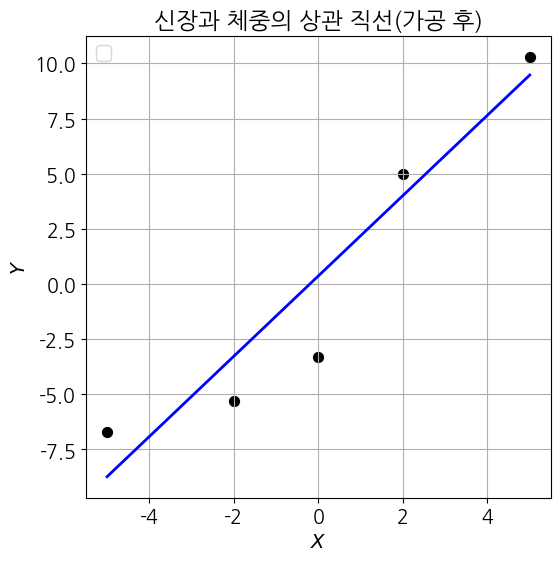

In [40]:
# 1. 최적화된 파라미터를 이용하여 산출한 회귀선용 데이터 준비
# X축의 범위를 정의 (최솟값에서 최댓값까지)
X_range = torch.tensor([X.min(), X.max()])

# 학습된 W와 B를 사용하여 예측값(Y) 계산
# .detach()를 사용하여 연산 그래프에서 분리한 뒤 계산합니다.
Y_range = W.detach() * X_range + B.detach()

# 2. 그래프 출력
plt.scatter(X, Y, c='k', s=50) # 원래 데이터 산점도
plt.xlabel('$X$')
plt.ylabel("$Y$")

plt.plot(X_range.numpy(), Y_range.numpy(), lw=2, c='b')
plt.title("신장과 체중의 상관 직선(가공 후)")
plt.legend()
plt.show()

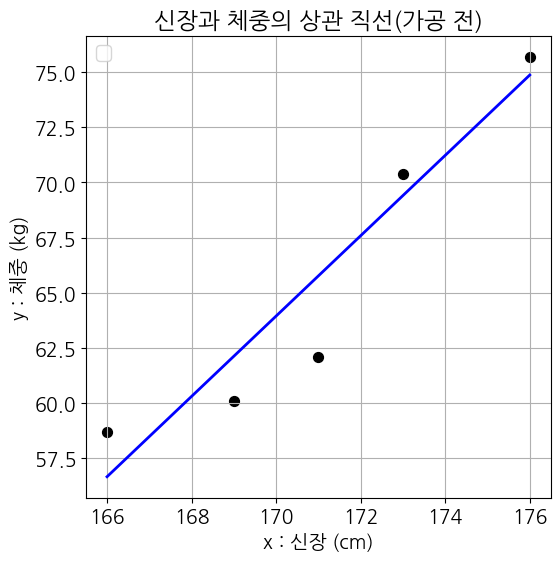

In [81]:
# 가공된 데이터를 다시 원래 단위로 되돌림 (평균 더하기)
x_plot = X_range.numpy() + x.mean()
y_plot = Y_range.numpy() + y.mean()

# 3. 그래프 출력
# 원본 데이터 sampleData1을 사용하여 점을 찍음
plt.scatter(x, y, c='k', s=50)
plt.xlabel('x : 신장 (cm)')
plt.ylabel('y : 체중 (kg)')

# 복원된 회귀선 그리기
plt.plot(x_plot, y_plot, lw=2, c='b')
plt.title("신장과 체중의 상관 직선(가공 전)")
plt.legend()
plt.show()

3.12 최적화 함수 step 함수 이용하기

In [84]:
# 초기화

W = torch.tensor(1.0, requires_grad=True).float()
B = torch.tensor(1.0, requires_grad=True).float()

num_epoch = 500

lr = 0.001

import torch.optim as optim
optimizer = optim.SGD([W, B], lr=lr)

history = torch.zeros((0,2))

In [85]:
# 루프처리
for epoch in range(num_epoch):
  Yp = pred(X)          # 예측
  loss = mse(Yp, Y)     # 손실 계산
  loss.backward()       # 경사 계산
  optimizer.step()      # 파라미터 수정
  optimizer.zero_grad()  # 경사값 초기화

  # 손실 기록
  if (epoch % 10 == 0):
    item = np.array([epoch, loss.item()])
    history = np.vstack([history, item])
    print(f'epoch = {epoch} loss = {loss:.4f}')

epoch = 0 loss = 13.3520
epoch = 10 loss = 10.3855
epoch = 20 loss = 8.5173
epoch = 30 loss = 7.3364
epoch = 40 loss = 6.5858
epoch = 50 loss = 6.1047
epoch = 60 loss = 5.7927
epoch = 70 loss = 5.5868
epoch = 80 loss = 5.4476
epoch = 90 loss = 5.3507
epoch = 100 loss = 5.2805
epoch = 110 loss = 5.2275
epoch = 120 loss = 5.1855
epoch = 130 loss = 5.1507
epoch = 140 loss = 5.1208
epoch = 150 loss = 5.0943
epoch = 160 loss = 5.0703
epoch = 170 loss = 5.0480
epoch = 180 loss = 5.0271
epoch = 190 loss = 5.0074
epoch = 200 loss = 4.9887
epoch = 210 loss = 4.9708
epoch = 220 loss = 4.9537
epoch = 230 loss = 4.9373
epoch = 240 loss = 4.9217
epoch = 250 loss = 4.9066
epoch = 260 loss = 4.8922
epoch = 270 loss = 4.8783
epoch = 280 loss = 4.8650
epoch = 290 loss = 4.8522
epoch = 300 loss = 4.8399
epoch = 310 loss = 4.8281
epoch = 320 loss = 4.8167
epoch = 330 loss = 4.8058
epoch = 340 loss = 4.7953
epoch = 350 loss = 4.7853
epoch = 360 loss = 4.7756
epoch = 370 loss = 4.7663
epoch = 380 loss = 4.

In [86]:
# 최종 파라미터 값
print(f"W = {W.data.numpy()}")
print(f"B = {B.data.numpy()}")

# 손실 확인
print(f"초기상태 = 손실 :{history[0,1]:.4f}")
print(f"초기상태 = 손실 :{history[-1,1]:.4f}")

W = 1.8206830024719238
B = 0.3675113916397095
초기상태 = 손실 :13.3520
초기상태 = 손실 :4.6796


In [87]:
# 초기화

W = torch.tensor(1.0, requires_grad=True).float()
B = torch.tensor(1.0, requires_grad=True).float()

num_epoch = 500

lr = 0.001

import torch.optim as optim
optimizer = optim.SGD([W, B], lr=lr, momentum=0.9)

history2 = torch.zeros((0,2))

In [88]:
# 루프처리
for epoch in range(num_epoch):
  Yp = pred(X)          # 예측
  loss = mse(Yp, Y)     # 손실 계산
  loss.backward()       # 경사 계산
  optimizer.step()      # 파라미터 수정
  optimizer.zero_grad()  # 경사값 초기화

  # 손실 기록
  if (epoch % 10 == 0):
    item = np.array([epoch, loss.item()])
    history2 = np.vstack([history2, item])
    print(f'epoch = {epoch} loss = {loss:.4f}')

epoch = 0 loss = 13.3520
epoch = 10 loss = 5.7585
epoch = 20 loss = 5.9541
epoch = 30 loss = 5.0276
epoch = 40 loss = 4.8578
epoch = 50 loss = 4.7052
epoch = 60 loss = 4.6327
epoch = 70 loss = 4.5940
epoch = 80 loss = 4.5698
epoch = 90 loss = 4.5574
epoch = 100 loss = 4.5495
epoch = 110 loss = 4.5452
epoch = 120 loss = 4.5426
epoch = 130 loss = 4.5411
epoch = 140 loss = 4.5403
epoch = 150 loss = 4.5398
epoch = 160 loss = 4.5395
epoch = 170 loss = 4.5393
epoch = 180 loss = 4.5392
epoch = 190 loss = 4.5391
epoch = 200 loss = 4.5391
epoch = 210 loss = 4.5391
epoch = 220 loss = 4.5391
epoch = 230 loss = 4.5390
epoch = 240 loss = 4.5390
epoch = 250 loss = 4.5390
epoch = 260 loss = 4.5390
epoch = 270 loss = 4.5390
epoch = 280 loss = 4.5390
epoch = 290 loss = 4.5390
epoch = 300 loss = 4.5390
epoch = 310 loss = 4.5390
epoch = 320 loss = 4.5390
epoch = 330 loss = 4.5390
epoch = 340 loss = 4.5390
epoch = 350 loss = 4.5390
epoch = 360 loss = 4.5390
epoch = 370 loss = 4.5390
epoch = 380 loss = 4.5

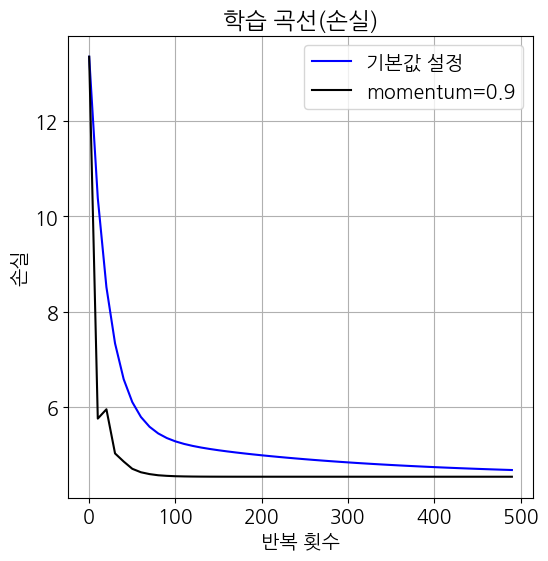

In [89]:
# 학습 곡선 출력(손실)

plt.plot(history[:,0], history[:,1], 'b', label="기본값 설정")
plt.plot(history2[:,0], history2[:,1], 'k', label="momentum=0.9")
plt.xlabel("반복 횟수")
plt.ylabel("손실")
plt.legend()
plt.title("학습 곡선(손실)")
plt.show()